In [1]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

### Exercise 2.1

In [26]:
# create data 
table21_d = {'n_at_risk': [10000,20000,30000,40000,50000],
             'n_standard': [12000000,16000000,20000000,24000000,28000000],
             'obs_cases': [6,15,75,160,360], 'stand_cases': [7200,16000,40000,72000,140000]}
table21 = pd.DataFrame(table21_d)
print(table21)

   n_at_risk  n_standard  obs_cases  stand_cases
0      10000    12000000          6         7200
1      20000    16000000         15        16000
2      30000    20000000         75        40000
3      40000    24000000        160        72000
4      50000    28000000        360       140000


In [22]:
# 2.1a direct calculation of standardized rate of disease

rj = table21['obs_cases']/table21['n_at_risk']        # observed incidence rate per age group
Ej = rj * table21['n_standard']                       # expected age-specific number of cases in population

direct = Ej.sum() / table21['n_standard'].sum()       # expected population rate, assuming observed rates apply
print(direct)

0.003668


In [23]:
# 2.1b indirect calculation of standardized rate of disease

rjs = table21['stand_cases']/table21['n_standard']    # incidence rate in the standard population
Ej2 = rjs * table21['n_at_risk']                      # expected age-specific number of cases in sample

indirect = Ej2.sum() / table21['n_at_risk'].sum()     # expected observed rate, assuming population rates apply
print(indirect)

0.00304


The direct and indirect standardized rates are fairly similar, at 0.0037 and 0.0030 respectively. 

Now consider an additional age stratum with few people at risk, and just a single observed case:

In [27]:
# add new row to table
table21.loc[5] = [10,10000000,1,100000]
print(table21)

   n_at_risk  n_standard  obs_cases  stand_cases
0      10000    12000000          6         7200
1      20000    16000000         15        16000
2      30000    20000000         75        40000
3      40000    24000000        160        72000
4      50000    28000000        360       140000
5         10    10000000          1       100000


In [30]:
# same calculations as before
rj = table21['obs_cases']/table21['n_at_risk']        
Ej = rj * table21['n_standard']                       

direct = Ej.sum() / table21['n_standard'].sum() 
print(round(direct,4))

rjs = table21['stand_cases']/table21['n_standard']
Ej2 = rjs * table21['n_at_risk']

indirect = Ej2.sum() / table21['n_at_risk'].sum()
print(round(indirect,4))

0.0124
0.003


With the addition of the age stratum with a low observation number, the indirect rate is unchanged, since applying the population rate to a sample group with such a small n-count has little effect on the overall sample rate. However, the standard rate is much larger than before, since the additional sample group has a high incidence rate, which changes the rate applied to the standard population.

### Exercise 2.2  

Consider the typical epidemiologic 2 × 2 table cross-classifying disease and exposure. To see the impact of both sample size and the rarity of the disease on the similarity between the relative risk and the odds ratio, consider a study with 1000 exposed and 1000 nonexposed subjects. Suppose that $ Pr(D^+|E^−)= 0.1$  and the relative risk is 2.0 (i.e., $ Pr(D^+|E^+)/Pr(D^+|E^−)= 2 $).

__2.2a Define the expected elements of the 2x2 table and calculate the odds ratio.__

|  | __$E^+$__ | __$E^-$__ |
|----------|----------|----------|
| __$D^+$__ | $n_{++} = 200$ | $n_{-+} = 100$ |
| __$D^-$__ | $n_{+-} = 800$ | $n_{--} = 900$ |
  
Odds Ratio:  
$$
\frac{(n_{++})(n_{--})}{(n_{+-})(n_{-+})} = \frac{180000}{80000} = 2.25
$$

  
__2.2b Repeat the calculation for $Pr(D^+|E^−)$ = 0.01, 0.001, 0.0001, and 0.00001. Discuss the relationship with between the relative risk and the odds ratio.__
  
odds ratio at 0.01    = 1.98  
odds ratio at 0.001   = 1.997  
odds ratio at 0.0001  = 1.999  

### Exercise 2.4

Consider the Scottish lip cancer data described and analyzed in Breslow and Clayton (1993). The data in Table 2.6 are the total number of observed and expected lip cancer cases in males in the 56 districts of Scotland during 1975–1980; the percentage of the district population employed in agriculture, fishing, and forestry (%AFF); and the longitude and latitude coordinate of the center of each district.

In [2]:
# read in data
SLC_data = pd.read_csv('ScottishLipCancerData.csv') 
print(SLC_data.head())

   District  Observed  Expected  %AFF  Longitude  Latitude
0         1         9       1.4    16      57.29      5.50
1         2        39       8.7    16      57.56      2.36
2         3        11       3.0    10      58.44      3.90
3         4         9       2.5    24      55.76      2.40
4         5        15       4.3    10      57.71      5.09


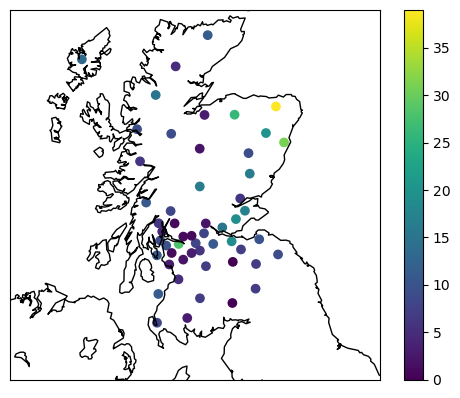

In [31]:
map = Basemap(lat_0 = 56.5, lon_0 = -4.2, width = 500000, height = 500000, resolution='i', projection='gnom')
map.drawcoastlines()

lon = SLC_data['Latitude']*-1
lat = SLC_data['Longitude']
obs = SLC_data['Observed']
map.scatter(lon, lat, latlon=True, c=obs)
plt.colorbar()

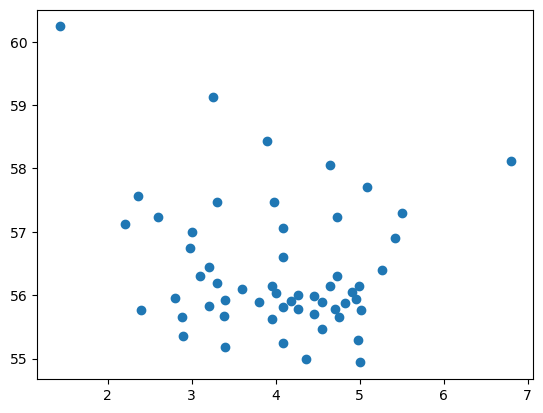

In [12]:
plt.scatter(SLC_data['Latitude'], SLC_data['Longitude'])
plt.show()

__2.4a__ Using linear regression, regress the observed number of lip cancer cases on the percentage engaged in agriculture, fishery, or forestry. What do you conclude about the effect of this covariate on the number of lip cancer in males? What are the assumptions of this regression? Are they valid for these data?

In [11]:
import statsmodels.api as sm

X = SLC_data['%AFF']
y = SLC_data['Observed']

# Add an intercept
X = sm.add_constant(X)

linearmodel = sm.OLS(endog=y, exog=X).fit()

print(linearmodel.summary())

                            OLS Regression Results                            
Dep. Variable:               Observed   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                    0.4204
Date:                Sat, 27 Dec 2025   Prob (F-statistic):              0.519
Time:                        13:50:44   Log-Likelihood:                -194.54
No. Observations:                  56   AIC:                             393.1
Df Residuals:                      54   BIC:                             397.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.6891      1.726      5.033      0.0

The covariate `%AFF` has a small but positive effect on the observed number of cases of lip cancer. A 1-percent increase in the percentage engaged in agriculture, fishery, or forestry is associated with a 0.102 increase in the number of cases of lip cancer.  

From the plot below we can see that the predictor is categorical, not continuous. While a linear regression model could still be fit, it would be better to fit a GLM.

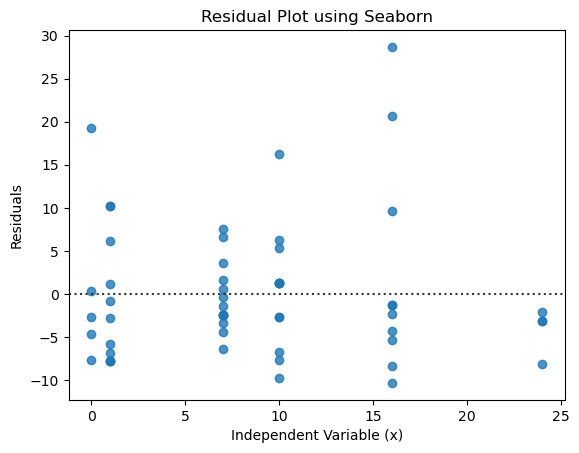

In [20]:
# plot the residuals
sns.residplot(x='%AFF', y='Observed', data=SLC_data)
plt.xlabel("Independent Variable (x)")
plt.ylabel("Residuals")
plt.title("Residual Plot using Seaborn")
plt.show()

__2.4b__ Perform the same regression, weighting by the expected number of lip cancer cases. Does this weighted regression help account for the violations in assumptions that you noted earlier? Do your conclusions change?

__2.4c__ Poisson Regression

In [5]:
poissonmodel = sm.GLM(SLC_data['Observed'], X, family=sm.families.Poisson())
poissonresults = poissonmodel.fit()

# View the model summary
print(poissonresults.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               Observed   No. Observations:                   56
Model:                            GLM   Df Residuals:                       55
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -568.52
Date:                Sat, 27 Dec 2025   Deviance:                       929.06
Time:                        13:32:28   Pearson chi2:                 2.46e+03
No. Iterations:                     6   Pseudo R-squ. (CS):         -4.649e+04
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1387      0.003     42.635      0.0

__2.4d__ including Latitude as an independent variable in both regressions

In [8]:
# linear regression
y = SLC_data['Observed']
X = SLC_data[['Latitude', '%AFF']]

# Add an intercept
X = sm.add_constant(X)

model1 = sm.OLS(endog=y, exog=X).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:               Observed   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     2.862
Date:                Sat, 27 Dec 2025   Prob (F-statistic):             0.0660
Time:                        13:42:36   Log-Likelihood:                -191.89
No. Observations:                  56   AIC:                             389.8
Df Residuals:                      53   BIC:                             395.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.1358      4.844      3.950      0.0

In [9]:
# Poisson Regression
model2 = sm.GLM(SLC_data['Observed'], X, family=sm.families.Poisson()).fit()

# 4. View the model summary
print(model2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               Observed   No. Observations:                   56
Model:                            GLM   Df Residuals:                       53
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -250.32
Date:                Sat, 27 Dec 2025   Deviance:                       292.66
Time:                        13:44:06   Pearson chi2:                     295.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.4606
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2207      0.197     16.358      0.0

From the results, we observe that in both cases, Latitude has negative and statistically significant effect on the observed number of cases. When the effect of latitude is considered, the effect of %AFF becomes small and no longer statistically significant. This indicates that %AFF has little effect on the observed number of cases once Latitude has been considered, suggesting that there is likely a confounding effect between latitude and %AFF.